# France Mobile Network QoS Analysis

## Radio conditions, throughput and Quality of Experience analysis

This project analyzes mobile network Quality of Service (QoS) measurments collected in metropolitan France by ARCEP.

The objective is to investigate how radio conditions — mainly **RSRP** and **RSRQ** — are associated with user-experienced performance across several service types:

- downlink throughput;
- uplink throughput;
- web browsing performance;
- video streaming quality;
- upload reliability.

The analysis also compares observed results across the four metropolitan mobile operators while accounting for protocol-specific metrics, sample sizes and data-quality limitations.

> The results describe the measurements contained in this dataset and should not be interpreted as a general ranking of mobile operators.


## 1. Environment and imports

Only the libraries required by the final analysis are imported here.


In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)


## 2. Data source and loading

The analysis uses the ARCEP 2025 metropolitan mobile QoS dataset for **habitation areas**.

Identifier columns are read as strings from the start so that leading zeros and administrative/network codes are preserved. The raw file uses a semicolon separator and comma decimal notation.


In [ ]:
DATA_DIR = Path("../data/raw")
CSV_PATH = DATA_DIR / "2025_QoS_Metropole_data_habitations.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {CSV_PATH.resolve()}")

CSV_PATH


In [ ]:
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    encoding="cp1252",
    decimal=",",
    dtype={
        "insee_com": "string",
        "mcc_start": "string",
        "mnc_start": "string",
    },
)

print("Raw shape:", df.shape)
df.head()


## 3. Data quality and preparation

The raw DataFrame is preserved unchanged. Cleaning is performed on a copy.

The portfolio keeps only transformations required for reproducible analysis. In particular, network and administrative identifer fields remain strings rather than being converted to numeric values.


In [ ]:
df_clean = df.copy()

empty_columns = df_clean.columns[df_clean.isna().all()].tolist()
df_clean = df_clean.drop(columns=empty_columns)

print("Empty columns removed:", len(empty_columns))
print("Clean shape:", df_clean.shape)


In [ ]:
numeric_columns_to_convert = [
    "rsrp",
    "rsrq",
    "latitude_start",
    "longitude_start",
]

missing_before = df_clean[numeric_columns_to_convert].isna().sum()

for col in numeric_columns_to_convert:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

missing_after = df_clean[numeric_columns_to_convert].isna().sum()

conversion_check = pd.DataFrame({
    "before": missing_before,
    "after": missing_after,
})
conversion_check["new_missing"] = conversion_check["after"] - conversion_check["before"]
conversion_check


In [ ]:
final_quality_checks = pd.Series({
    "rows": len(df_clean),
    "columns": df_clean.shape[1],
    "removed_empty_columns": len(empty_columns),
    "fully_empty_columns_remaining": int(df_clean.isna().all().sum()),
    "duplicate_rows": int(df_clean.duplicated().sum()),
})

final_quality_checks


In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_pct": df_clean.isna().mean().mul(100),
    "dtype": df_clean.dtypes.astype(str),
}).sort_values("missing_pct", ascending=False)

missing_summary.head(20)


### 3.1 Protocol-specific metric availability

The dataset contains several test protocols. Metrics are therefore analyzed only within the protocol for which they are actually populated, avoiding comparisons between indicators with different meanings.


In [ ]:
qos_metrics = [
    "acess_duration",
    "bitrate_dl",
    "bitrate_ul",
    "transfert_file_size",
    "loaded_in_less_5_secondes",
    "loaded_in_less_10_secondes",
    "upload_ok",
    "quality_correct",
    "quality_perfect",
]

protocol_metric_counts = (
    df_clean
    .groupby("protocole", dropna=False)[qos_metrics]
    .count()
    .T
)

protocol_metric_counts


In [ ]:
result_by_protocol = pd.crosstab(
    df_clean["protocole"],
    df_clean["Result"],
    dropna=False,
    margins=True,
)

result_by_protocol


## 4. Analysis conventions

Two regular radio bins are used throughout the notebook:

- **RSRP:** 10 dB intervals;
- **RSRQ:** 5 dB intervals.

For line charts, groups containing fewer than **100 observations** are hidden from the visualization only. The underlying observations are not deleted and remain present in the statistical tables. This threshold is a portfolio visualization rule, not a telecom standard.

Pearson and Spearman coefficients are used as complementary association measures. Correlation does not imply causation.


In [ ]:
RSRP_BINS_10DB = [
    -160, -150, -140, -130, -120,
    -110, -100, -90, -80, -70,
    -60, -50,
]

RSRQ_BINS_5DB = [-30, -25, -20, -15, -10, -5, 0]
MIN_GROUP_SIZE = 100


## 5. Radio conditions

The radio layer is examined first because RSRP and RSRQ provide the physical context for the QoS results that follow.

- **RSRP** describes received reference-signal power and is mainly used here as a coverage/received-level indicator.
- **RSRQ** combines signal quality with the surrounding received power and is therefore useful for describing the quality of the radio environment.

The objective of this section is not to define universal "good" or "bad" thresholds. Instead, it describes the distributions observed in this ARCEP campaign and compares the four operators before any user-experience KPI is introduced.


In [ ]:
radio_metrics = ["rsrp", "rsrq"]
df_clean[radio_metrics].describe().round(2)


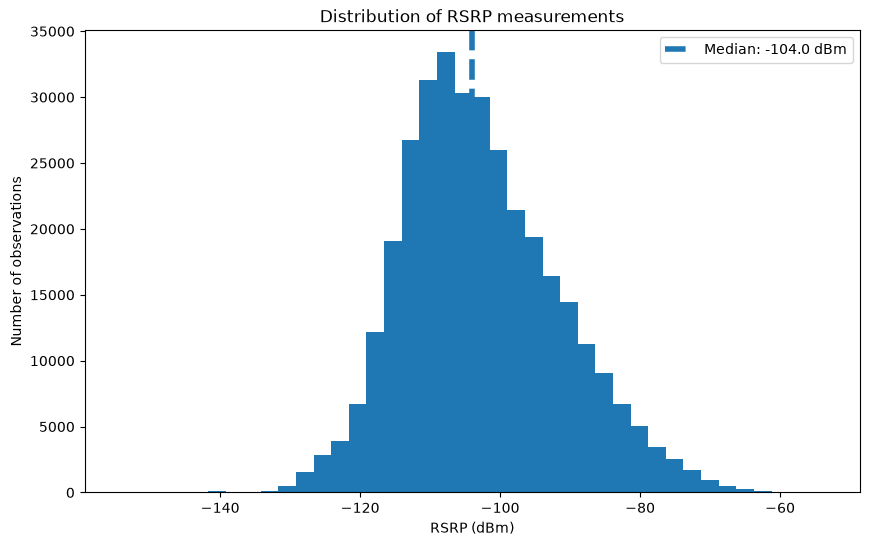

In [ ]:
rsrp_values = df_clean["rsrp"].dropna()
rsrp_median = rsrp_values.median()

plt.figure(figsize=(10, 6))
plt.hist(rsrp_values, bins=40)
plt.axvline(
    rsrp_median,
    linestyle="--",
    linewidth=2,
    label=f"Median: {rsrp_median:.1f} dBm",
)
plt.xlabel("RSRP (dBm)")
plt.ylabel("Number of observations")
plt.title("Distribution of RSRP measurements")
plt.legend()
plt.tight_layout()
plt.show()


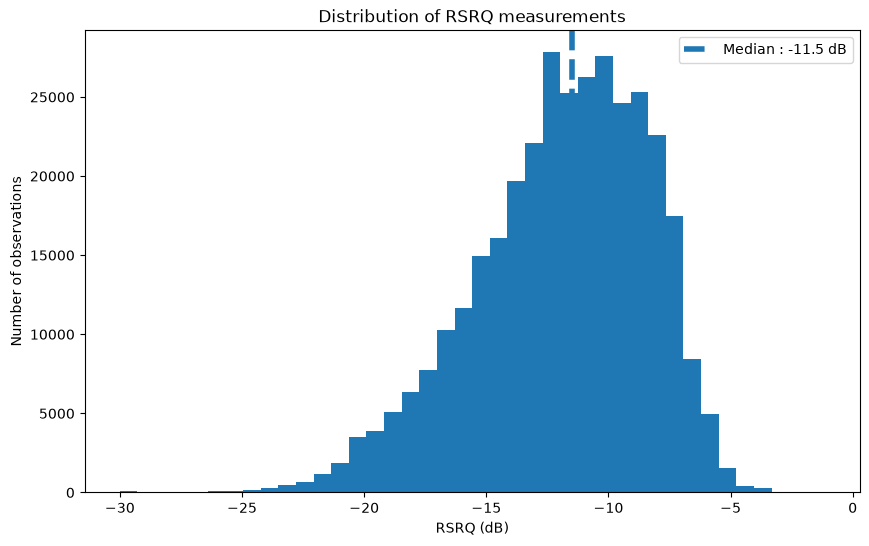

In [ ]:
rsrq_values = df_clean["rsrq"].dropna()
rsrq_median = rsrq_values.median()

plt.figure(figsize=(10, 6))
plt.hist(rsrq_values, bins=40)
plt.axvline(
    rsrq_median,
    linestyle="--",
    linewidth=2,
    label=f"Median: {rsrq_median:.1f} dB",
)
plt.xlabel("RSRQ (dB)")
plt.ylabel("Number of observations")
plt.title("Distribution of RSRQ measurements")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
radio_stats_by_operator = (
    df_clean
    .groupby("operator")[["rsrp", "rsrq"]]
    .agg(["count", "median"])
    .round(2)
)

radio_stats_by_operator


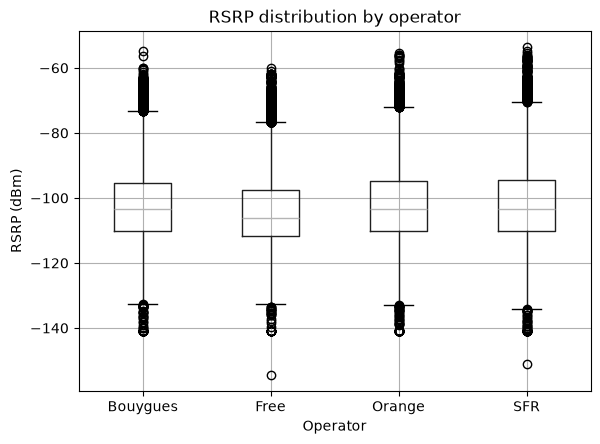

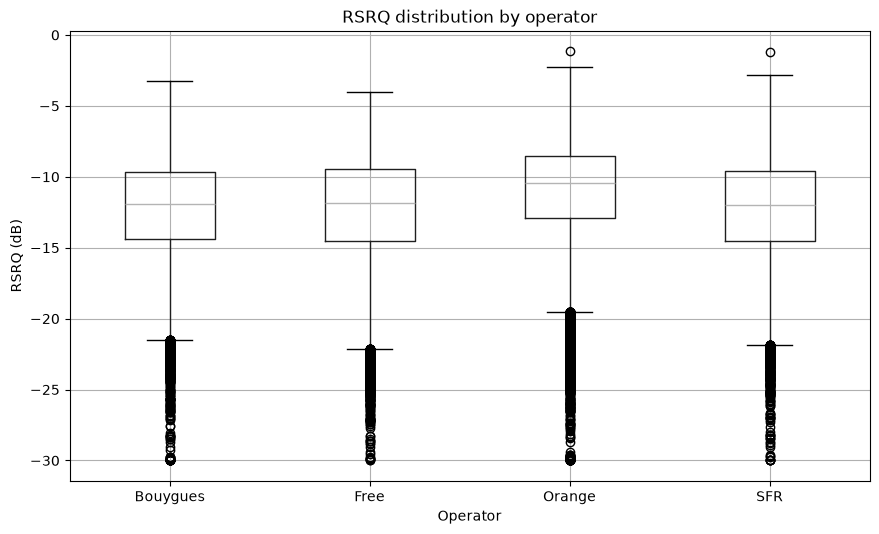

In [ ]:
ax = df_clean.boxplot(
    column="rsrp",
    by="operator",
    figsize=(10, 6),
    showfliers=False,
)
ax.set_xlabel("Operator")
ax.set_ylabel("RSRP (dBm)")
ax.set_title("RSRP distribution by operator")
plt.suptitle("")
plt.tight_layout()
plt.show()

ax = df_clean.boxplot(
    column="rsrq",
    by="operator",
    figsize=(10, 6),
    showfliers=False,
)
ax.set_xlabel("Operator")
ax.set_ylabel("RSRQ (dB)")
ax.set_title("RSRQ distribution by operator")
plt.suptitle("")
plt.tight_layout()
plt.show()


### Radio observations

The campaign contains more than 338,000 usable RSRP/RSRQ observations, which gives a broad basis for describing the radio environment of the measurements.

The operator boxplots should be read as **distributions**, not as a ranking. Their medians are not identical, but the interquartile ranges overlap substantially. This means that a large share of the measurements from different operators was collected under comparable radio conditions.

That overlap is important for the rest of the notebook: it justifies looking beyond raw radio levels and asking a more engineering-oriented question — **for comparable RSRP or RSRQ ranges, how do the service KPIs behave?**

`showfliers=False` is used only to keep the plots readable; no observation is removed from the dataset or from the numerical analysis.


## 6. Throughput analysis

Throughput is analyzed separately for downlink and uplink because the two directions do not necessarily react to radio conditions in the same way.

Three complementary views are used:

1. **Global correlation** to quantify the overall association between radio conditions and bitrate.
2. **Binned median curves** to reveal nonlinear behaviour that a single correlation coefficient can hide.
3. **Operator-level comparisons at comparable radio levels** to separate, as far as this dataset allows, differences in radio conditions from differences in observed service performance.

The analysis remains descriptive: similar RSRP/RSRQ values do not guarantee identical spectrum, load, scheduler configuration, device capabilities or transport conditions.

### 6.1 Downlink throughput

Downlink bitrate is analyzed only for rows where RSRP, RSRQ and `bitrate_dl` are simultaneously available. This avoids creating correlations from rows where one of the required variables is missing.

Both Pearson and Spearman are retained. Pearson captures linear association, while Spearman is especially useful here because bitrate-versus-radio relationships are monotonic but visibly nonlinear and can approach a plateau.


In [ ]:
radio_qos_dl = (
    df_clean[["operator", "protocole", "rsrp", "rsrq", "bitrate_dl"]]
    .dropna(subset=["rsrp", "rsrq", "bitrate_dl"])
    .copy()
)

print("Shape:", radio_qos_dl.shape)
print(radio_qos_dl["protocole"].value_counts(dropna=False))
radio_qos_dl["bitrate_dl"].describe().round(2)


In [ ]:
dl_corr_pearson = (
    radio_qos_dl[["rsrp", "rsrq", "bitrate_dl"]]
    .corr(method="pearson")
    .round(3)
)

dl_corr_spearman = (
    radio_qos_dl[["rsrp", "rsrq", "bitrate_dl"]]
    .corr(method="spearman")
    .round(3)
)

print("Pearson")
display(dl_corr_pearson)
print("Spearman")
display(dl_corr_spearman)


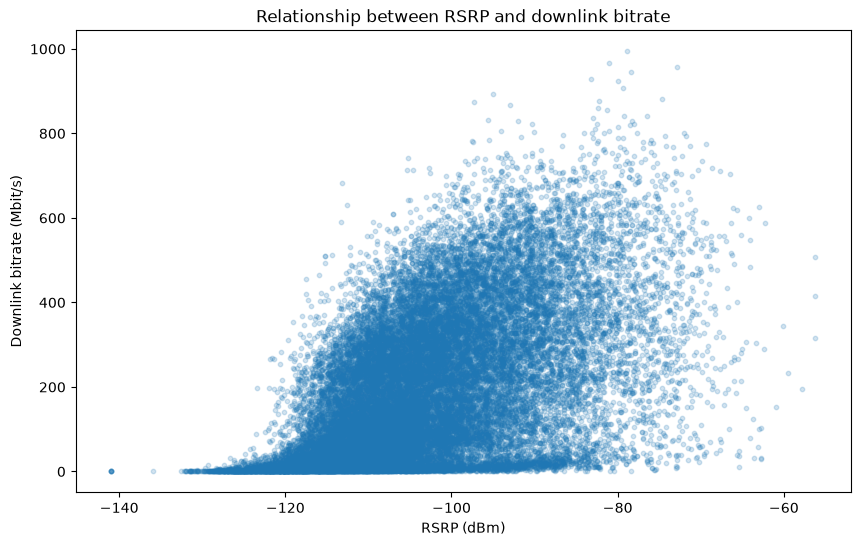

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(
    radio_qos_dl["rsrp"],
    radio_qos_dl["bitrate_dl"],
    alpha=0.2,
    s=10,
)
plt.xlabel("RSRP (dBm)")
plt.ylabel("Downlink bitrate (Mbit/s)")
plt.title("Relationship between RSRP and downlink bitrate")
plt.tight_layout()
plt.show()


In [ ]:
radio_qos_dl["rsrp_bin_10db"] = pd.cut(
    radio_qos_dl["rsrp"], bins=RSRP_BINS_10DB
)
radio_qos_dl["rsrq_bin_5db"] = pd.cut(
    radio_qos_dl["rsrq"], bins=RSRQ_BINS_5DB
)

dl_rsrp_stats = (
    radio_qos_dl
    .groupby("rsrp_bin_10db", observed=True)["bitrate_dl"]
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
)

dl_rsrq_stats = (
    radio_qos_dl
    .groupby("rsrq_bin_5db", observed=True)["bitrate_dl"]
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
)

print("DL by RSRP range")
display(dl_rsrp_stats)
print("DL by RSRQ range")
display(dl_rsrq_stats)


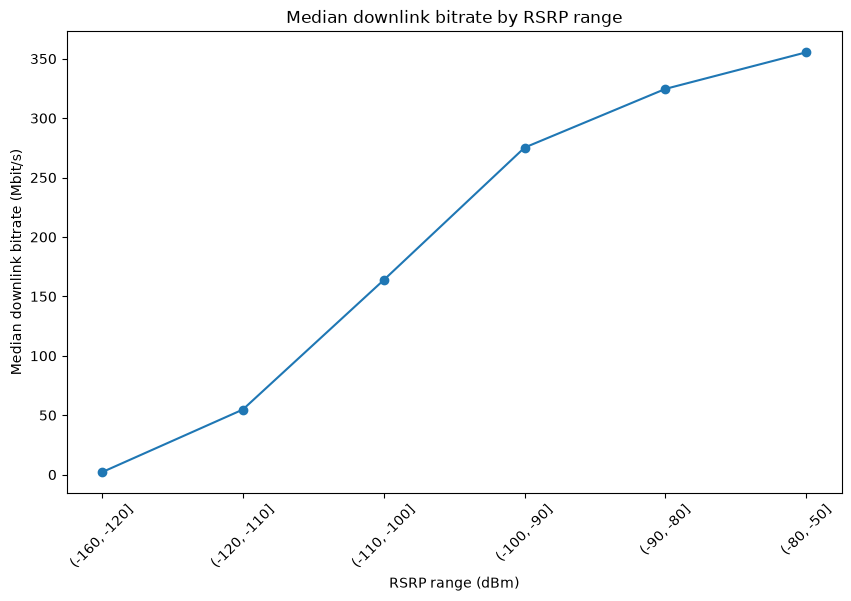

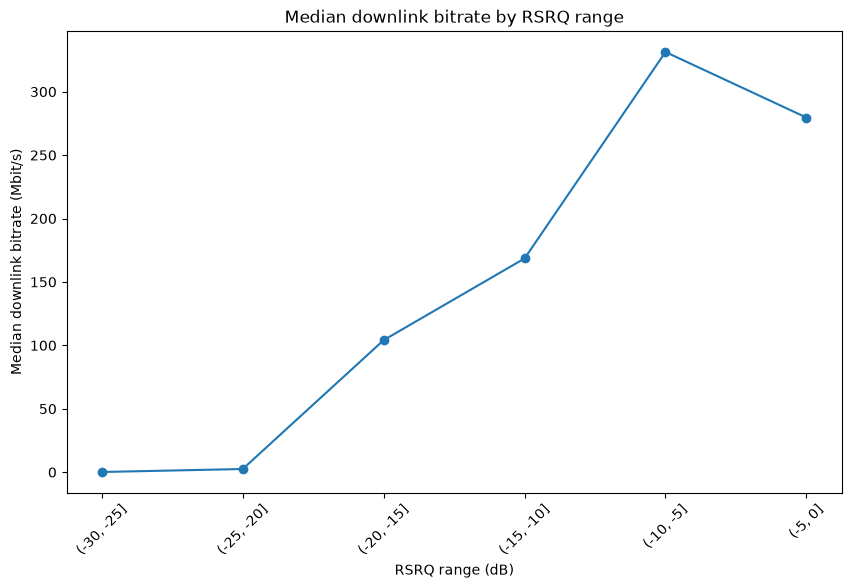

In [ ]:
dl_rsrp_plot = dl_rsrp_stats["50%"].copy()
dl_rsrp_plot[dl_rsrp_stats["count"] < MIN_GROUP_SIZE] = pd.NA

plt.figure(figsize=(10, 6))
plt.plot(dl_rsrp_plot.index.astype(str), dl_rsrp_plot.values, marker="o")
plt.xlabel("RSRP range (dBm)")
plt.ylabel("Median downlink bitrate (Mbit/s)")
plt.title("Median downlink bitrate by RSRP range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


dl_rsrq_plot = dl_rsrq_stats["50%"].copy()
dl_rsrq_plot[dl_rsrq_stats["count"] < MIN_GROUP_SIZE] = pd.NA

plt.figure(figsize=(10, 6))
plt.plot(dl_rsrq_plot.index.astype(str), dl_rsrq_plot.values, marker="o")
plt.xlabel("RSRQ range (dB)")
plt.ylabel("Median downlink bitrate (Mbit/s)")
plt.title("Median downlink bitrate by RSRQ range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
dl_stats_by_operator = (
    radio_qos_dl
    .groupby("operator")["bitrate_dl"]
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
)

dl_stats_by_operator


### 6.1.1 Downlink comparison by operator at comparable radio levels

A raw operator bitrate comparison can be misleading if one operator was measured more often under stronger or weaker radio conditions. To reduce that bias, the following plots compare the **median DL bitrate inside the same RSRP or RSRQ bins**.

For each operator × radio-bin combination, the median is plotted only when at least 100 observations are available. The masking affects the figure only; the full grouped medians and counts are still computed and remain available for inspection.

This view does not create a controlled experiment, but it is more informative than comparing only one global bitrate median per operator.


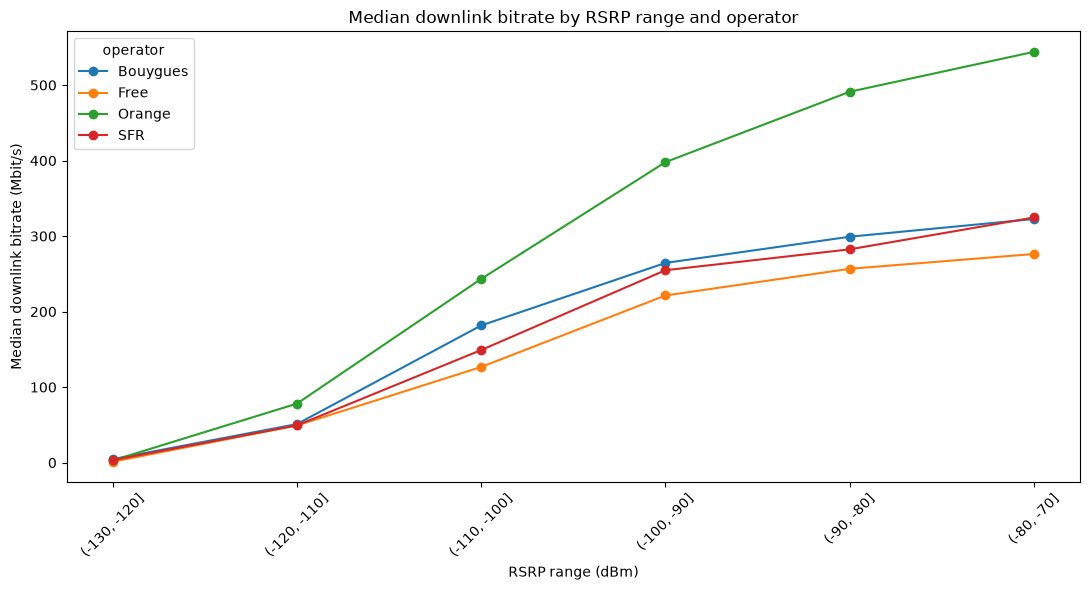

In [ ]:
dl_rsrp_operator_counts = (
    radio_qos_dl
    .groupby(["rsrp_bin_10db", "operator"], observed=True)
    .size()
    .unstack(fill_value=0)
)

dl_rsrp_operator_median = (
    radio_qos_dl
    .groupby(["rsrp_bin_10db", "operator"], observed=True)["bitrate_dl"]
    .median()
    .unstack()
    .round(2)
)

dl_rsrp_operator_plot = dl_rsrp_operator_median.copy()
dl_rsrp_operator_plot[dl_rsrp_operator_counts < MIN_GROUP_SIZE] = pd.NA

ax = dl_rsrp_operator_plot.plot(marker="o", figsize=(11, 6))
ax.set_xlabel("RSRP range (dBm)")
ax.set_ylabel("Median downlink bitrate (Mbit/s)")
ax.set_title("Median downlink bitrate by RSRP range and operator")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation.** The curves preserve the same overall trend: DL bitrate increases as RSRP improves, but the operator trajectories are not identical. In several central RSRP classes, Orange shows a higher observed median DL bitrate than the other operators in this campaign. This should be read as a **conditional observation at similar RSRP**, not as a causal or nationwide operator ranking.


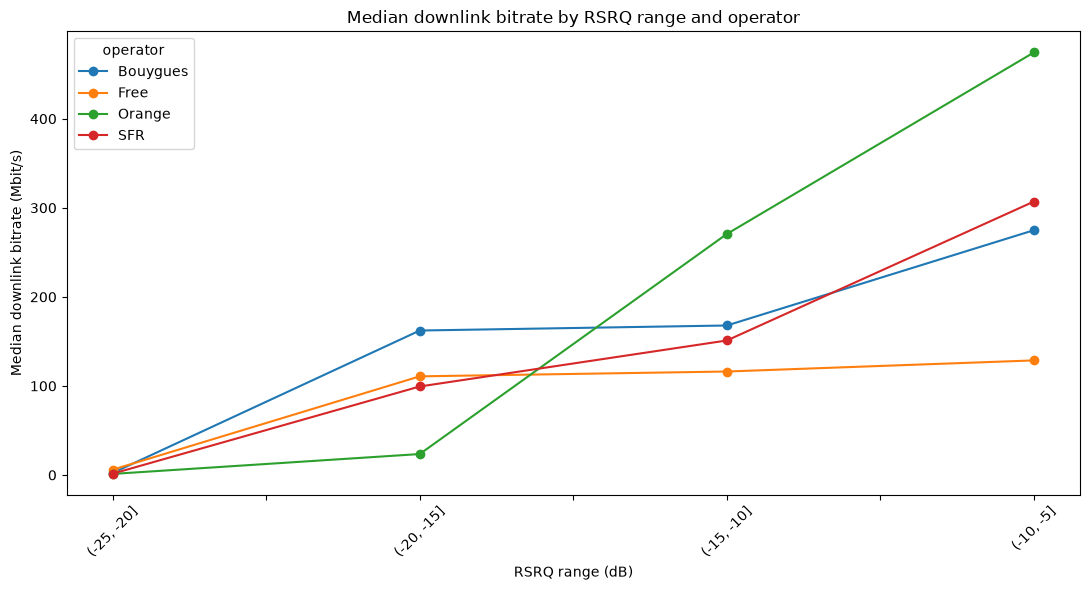

In [ ]:
dl_rsrq_operator_counts = (
    radio_qos_dl
    .groupby(["rsrq_bin_5db", "operator"], observed=True)
    .size()
    .unstack(fill_value=0)
)

dl_rsrq_operator_median = (
    radio_qos_dl
    .groupby(["rsrq_bin_5db", "operator"], observed=True)["bitrate_dl"]
    .median()
    .unstack()
    .round(2)
)

dl_rsrq_operator_plot = dl_rsrq_operator_median.copy()
dl_rsrq_operator_plot[dl_rsrq_operator_counts < MIN_GROUP_SIZE] = pd.NA

ax = dl_rsrq_operator_plot.plot(marker="o", figsize=(11, 6))
ax.set_xlabel("RSRQ range (dB)")
ax.set_ylabel("Median downlink bitrate (Mbit/s)")
ax.set_title("Median downlink bitrate by RSRQ range and operator")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation.** RSRQ also separates low- and high-performance conditions, although the relationship is less strong than for RSRP in the global DL correlations. The spread between operator curves shows that comparable RSRQ does not imply comparable throughput; other radio-resource and network factors remain influential.


In [ ]:
dl_operator_correlations = []

for operator in radio_qos_dl["operator"].dropna().unique():
    operator_data = radio_qos_dl[radio_qos_dl["operator"] == operator]

    dl_operator_correlations.append({
        "operator": operator,
        "count": len(operator_data),
        "rsrp_pearson": operator_data["rsrp"].corr(
            operator_data["bitrate_dl"], method="pearson"
        ),
        "rsrp_spearman": operator_data["rsrp"].corr(
            operator_data["bitrate_dl"], method="spearman"
        ),
        "rsrq_pearson": operator_data["rsrq"].corr(
            operator_data["bitrate_dl"], method="pearson"
        ),
        "rsrq_spearman": operator_data["rsrq"].corr(
            operator_data["bitrate_dl"], method="spearman"
        ),
    })

dl_operator_correlations = pd.DataFrame(dl_operator_correlations).round(3)
dl_operator_correlations


### 6.2 Uplink throughput

The same workflow is applied to uplink measurements so that DL and UL can be compared on a consistent basis.

The uplink relationship is particularly interesting from a radio-engineering perspective because terminal transmit power is constrained. As radio conditions deteriorate, the UE has less margin to compensate for path loss and interference, so the UL can become more directly dependent on the radio link.

The notebook therefore compares not only the global UL trend, but also the consistency of that trend across operators and across RSRP/RSRQ ranges.


In [ ]:
radio_qos_ul = (
    df_clean[["operator", "protocole", "rsrp", "rsrq", "bitrate_ul"]]
    .dropna(subset=["rsrp", "rsrq", "bitrate_ul"])
    .copy()
)

print("Shape:", radio_qos_ul.shape)
print(radio_qos_ul["protocole"].value_counts(dropna=False))
radio_qos_ul["bitrate_ul"].describe().round(2)


In [ ]:
ul_corr_pearson = (
    radio_qos_ul[["rsrp", "rsrq", "bitrate_ul"]]
    .corr(method="pearson")
    .round(3)
)

ul_corr_spearman = (
    radio_qos_ul[["rsrp", "rsrq", "bitrate_ul"]]
    .corr(method="spearman")
    .round(3)
)

print("Pearson")
display(ul_corr_pearson)
print("Spearman")
display(ul_corr_spearman)


In [ ]:
radio_qos_ul["rsrp_bin_10db"] = pd.cut(
    radio_qos_ul["rsrp"], bins=RSRP_BINS_10DB
)
radio_qos_ul["rsrq_bin_5db"] = pd.cut(
    radio_qos_ul["rsrq"], bins=RSRQ_BINS_5DB
)

ul_rsrp_stats = (
    radio_qos_ul
    .groupby("rsrp_bin_10db", observed=True)["bitrate_ul"]
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
)

ul_rsrq_stats = (
    radio_qos_ul
    .groupby("rsrq_bin_5db", observed=True)["bitrate_ul"]
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
)

print("UL by RSRP range")
display(ul_rsrp_stats)
print("UL by RSRQ range")
display(ul_rsrq_stats)


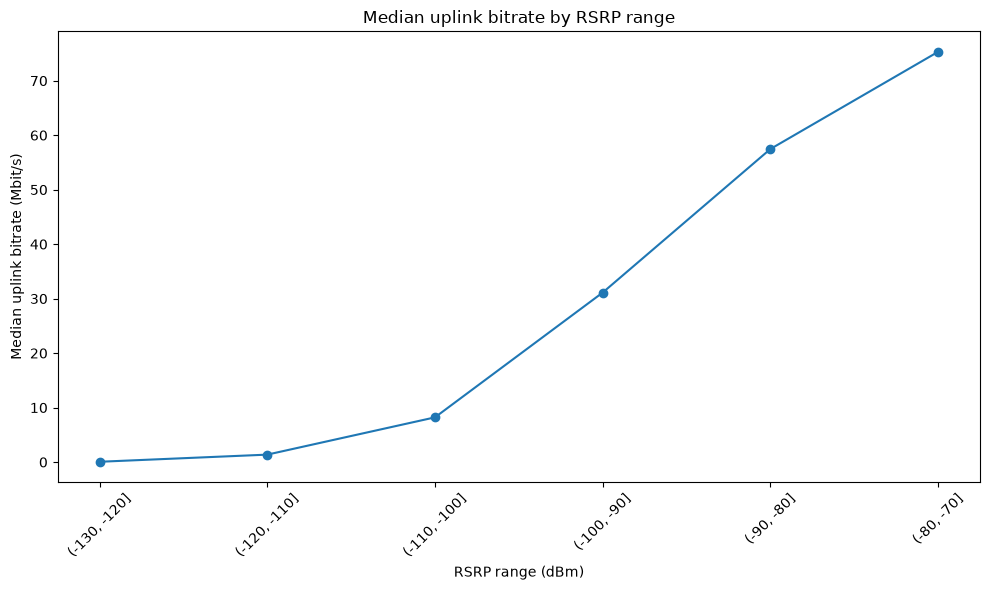

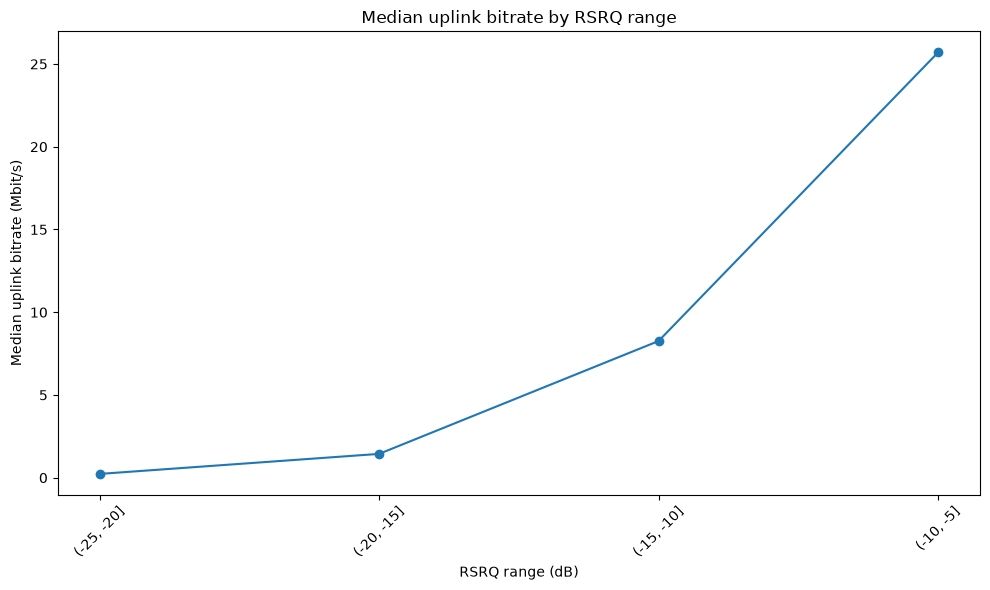

In [ ]:
ul_rsrp_plot = ul_rsrp_stats["50%"].copy()
ul_rsrp_plot[ul_rsrp_stats["count"] < MIN_GROUP_SIZE] = pd.NA

plt.figure(figsize=(10, 6))
plt.plot(ul_rsrp_plot.index.astype(str), ul_rsrp_plot.values, marker="o")
plt.xlabel("RSRP range (dBm)")
plt.ylabel("Median uplink bitrate (Mbit/s)")
plt.title("Median uplink bitrate by RSRP range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ul_rsrq_plot = ul_rsrq_stats["50%"].copy()
ul_rsrq_plot[ul_rsrq_stats["count"] < MIN_GROUP_SIZE] = pd.NA

plt.figure(figsize=(10, 6))
plt.plot(ul_rsrq_plot.index.astype(str), ul_rsrq_plot.values, marker="o")
plt.xlabel("RSRQ range (dB)")
plt.ylabel("Median uplink bitrate (Mbit/s)")
plt.title("Median uplink bitrate by RSRQ range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
ul_stats_by_operator = (
    radio_qos_ul
    .groupby("operator")["bitrate_ul"]
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
)

ul_stats_by_operator


### 6.2.1 Uplink comparison by operator at comparable radio levels

The same conditional comparison is repeated for UL. This is useful because the global UL analysis already shows a much stronger association with RSRP than the DL analysis.

Plotting the four operators inside common radio bins allows us to check whether that strong UL trend is shared across networks rather than being driven by only one operator or by an imbalanced radio distribution.


In [ ]:
ul_rsrp_operator_counts = (
    radio_qos_ul
    .groupby(["rsrp_bin_10db", "operator"], observed=True)
    .size()
    .unstack(fill_value=0)
)

ul_rsrp_operator_median = (
    radio_qos_ul
    .groupby(["rsrp_bin_10db", "operator"], observed=True)["bitrate_ul"]
    .median()
    .unstack()
    .round(2)
)

ul_rsrp_operator_plot = ul_rsrp_operator_median.copy()
ul_rsrp_operator_plot[ul_rsrp_operator_counts < MIN_GROUP_SIZE] = pd.NA

ax = ul_rsrp_operator_plot.plot(marker="o", figsize=(11, 6))
ax.set_xlabel("RSRP range (dBm)")
ax.set_ylabel("Median uplink bitrate (Mbit/s)")
ax.set_title("Median uplink bitrate by RSRP range and operator")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation.** The UL curves rise strongly with improving RSRP for all four operators. Together with the operator-level Spearman coefficients, this supports one of the clearest findings of the project: the **RSRP–UL relationship is strong and comparatively stable across operators** in this measurement sample.


In [ ]:
ul_rsrq_operator_counts = (
    radio_qos_ul
    .groupby(["rsrq_bin_5db", "operator"], observed=True)
    .size()
    .unstack(fill_value=0)
)

ul_rsrq_operator_median = (
    radio_qos_ul
    .groupby(["rsrq_bin_5db", "operator"], observed=True)["bitrate_ul"]
    .median()
    .unstack()
    .round(2)
)

ul_rsrq_operator_plot = ul_rsrq_operator_median.copy()
ul_rsrq_operator_plot[ul_rsrq_operator_counts < MIN_GROUP_SIZE] = pd.NA

ax = ul_rsrq_operator_plot.plot(marker="o", figsize=(11, 6))
ax.set_xlabel("RSRQ range (dB)")
ax.set_ylabel("Median uplink bitrate (Mbit/s)")
ax.set_title("Median uplink bitrate by RSRQ range and operator")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation.** UL bitrate also improves with RSRQ, but the operator-level correlations are more heterogeneous than for RSRP. RSRQ is therefore informative, yet RSRP provides the more consistent radio-to-UL relationship across the four operators in this dataset.


In [ ]:
ul_operator_correlations = []

for operator in radio_qos_ul["operator"].dropna().unique():
    operator_data = radio_qos_ul[radio_qos_ul["operator"] == operator]

    ul_operator_correlations.append({
        "operator": operator,
        "count": len(operator_data),
        "rsrp_pearson": operator_data["rsrp"].corr(
            operator_data["bitrate_ul"], method="pearson"
        ),
        "rsrp_spearman": operator_data["rsrp"].corr(
            operator_data["bitrate_ul"], method="spearman"
        ),
        "rsrq_pearson": operator_data["rsrq"].corr(
            operator_data["bitrate_ul"], method="pearson"
        ),
        "rsrq_spearman": operator_data["rsrq"].corr(
            operator_data["bitrate_ul"], method="spearman"
        ),
    })

ul_operator_correlations = pd.DataFrame(ul_operator_correlations).round(3)
ul_operator_correlations


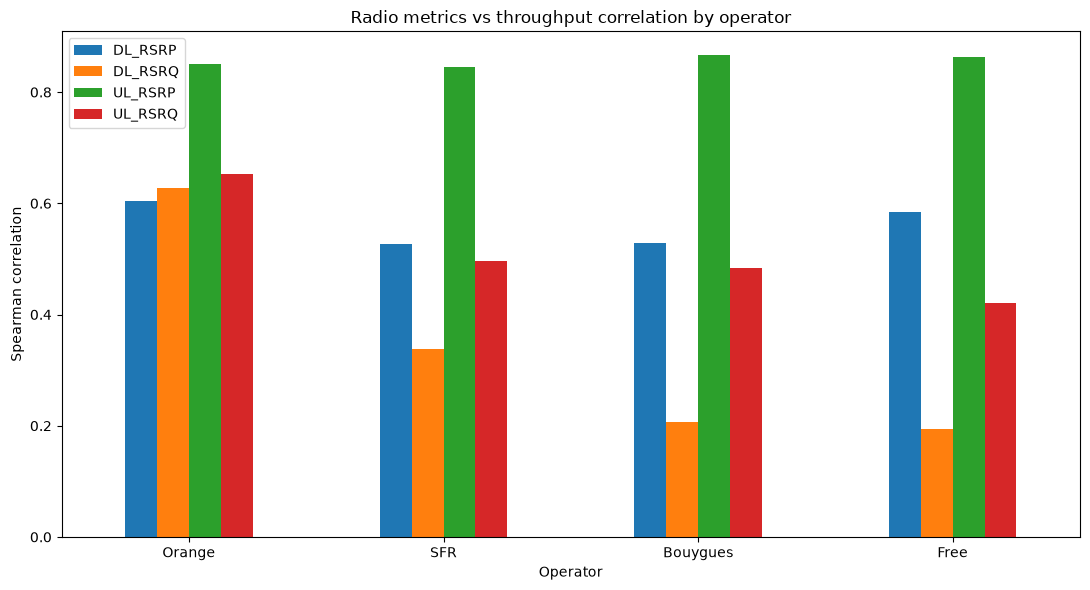

In [ ]:
radio_throughput_summary = pd.DataFrame({
    "DL_RSRP": dl_operator_correlations.set_index("operator")["rsrp_spearman"],
    "DL_RSRQ": dl_operator_correlations.set_index("operator")["rsrq_spearman"],
    "UL_RSRP": ul_operator_correlations.set_index("operator")["rsrp_spearman"],
    "UL_RSRQ": ul_operator_correlations.set_index("operator")["rsrq_spearman"],
}).round(3)

display(radio_throughput_summary)

ax = radio_throughput_summary.plot(
    kind="bar",
    figsize=(11, 6),
)
ax.set_ylabel("Spearman correlation")
ax.set_title("Radio-to-throughput association by operator")
ax.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Throughput findings

The throughput analysis shows several distinct behaviours rather than a single "radio quality = speed" relationship:

- **Downlink:** bitrate generally rises as RSRP and RSRQ improve, but the dispersion remains large. This is consistent with the fact that DL performance also depends strongly on bandwidth, load, scheduling, MIMO conditions, device capabilities and transport/server effects.
- **RSRP vs RSRQ in DL:** the global Spearman association is stronger for **RSRP → DL bitrate** than for **RSRQ → DL bitrate** in this sample.
- **Uplink:** the relationship with RSRP is much stronger and more homogeneous. The global Spearman coefficient is around 0.85, and all four operator-level values remain high.
- **Comparable-radio operator curves:** differences remain visible even inside the same RSRP/RSRQ classes. These gaps are useful observations, but they must not be interpreted as proof that the operator itself is the causal factor because the other network conditions are not controlled.

The binned curves are therefore the main engineering view, while the correlation coefficients act as compact supporting indicators.


## 7. WEB Quality of Experience

WEB tests are analyzed through two complementary dimensions: **reliability** (whether the page is loaded within 5 or 10 seconds) and **responsiveness** (`acess_duration`). The main performace question is whether better radio conditions are associated with faster and more reliable page loading.

The two loading indicators are binary. Their mean therefore has a direct interpretation as a success proportion; multiplying by 100 gives the success rate in percent.

This protocol also illustrates why data-quality checks matter: a duration value is not automatically a normal successful measurement. Timeout observations must be identified before interpreting access time statistically.


In [ ]:
web_qos = (
    df_clean.loc[
        df_clean["protocole"] == "WEB",
        [
            "operator",
            "rsrp",
            "rsrq",
            "acess_duration",
            "loaded_in_less_5_secondes",
            "loaded_in_less_10_secondes",
            "Result",
        ],
    ]
    .copy()
)

web_success_by_operator = (
    web_qos
    .groupby("operator")[[
        "loaded_in_less_5_secondes",
        "loaded_in_less_10_secondes",
    ]]
    .mean()
    .mul(100)
    .round(2)
)

web_success_by_operator["between_5_and_10_pp"] = (
    web_success_by_operator["loaded_in_less_10_secondes"]
    - web_success_by_operator["loaded_in_less_5_secondes"]
).round(2)

web_success_by_operator


In [ ]:
web_timing_inconsistency = (
    (web_qos["loaded_in_less_5_secondes"] == 1)
    & (web_qos["loaded_in_less_10_secondes"] == 0)
)

print("Logical 5s/10s inconsistencies:", int(web_timing_inconsistency.sum()))

web_qos["rsrp_bin_10db"] = pd.cut(web_qos["rsrp"], bins=RSRP_BINS_10DB)
web_qos["rsrq_bin_5db"] = pd.cut(web_qos["rsrq"], bins=RSRQ_BINS_5DB)


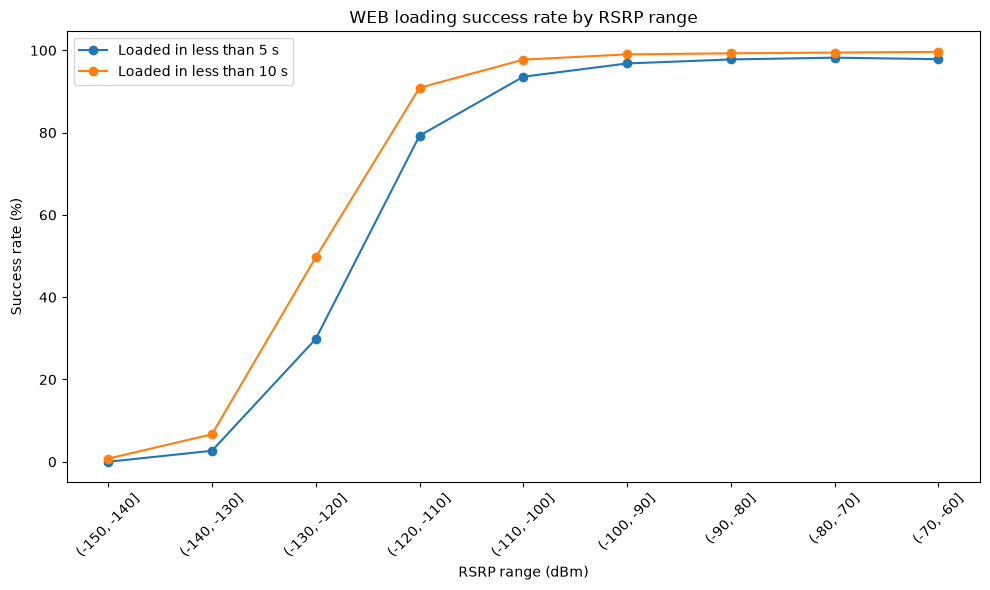

In [ ]:
web_rsrp_quality = (
    web_qos
    .groupby("rsrp_bin_10db", observed=True)[[
        "loaded_in_less_5_secondes",
        "loaded_in_less_10_secondes",
    ]]
    .agg(["count", "mean"])
)

web_rsrp_summary = pd.DataFrame({
    "count": web_rsrp_quality[("loaded_in_less_5_secondes", "count")],
    "under_5_pct": web_rsrp_quality[("loaded_in_less_5_secondes", "mean")] * 100,
    "under_10_pct": web_rsrp_quality[("loaded_in_less_10_secondes", "mean")] * 100,
}).round(2)

web_rsrp_plot = web_rsrp_summary.copy()
web_rsrp_plot.loc[
    web_rsrp_plot["count"] < MIN_GROUP_SIZE,
    ["under_5_pct", "under_10_pct"],
] = pd.NA

display(web_rsrp_summary)

plt.figure(figsize=(10, 6))
plt.plot(web_rsrp_plot.index.astype(str), web_rsrp_plot["under_5_pct"], marker="o", label="Loaded < 5 s")
plt.plot(web_rsrp_plot.index.astype(str), web_rsrp_plot["under_10_pct"], marker="o", label="Loaded < 10 s")
plt.xlabel("RSRP range (dBm)")
plt.ylabel("WEB success rate (%)")
plt.title("WEB loading success by RSRP range")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


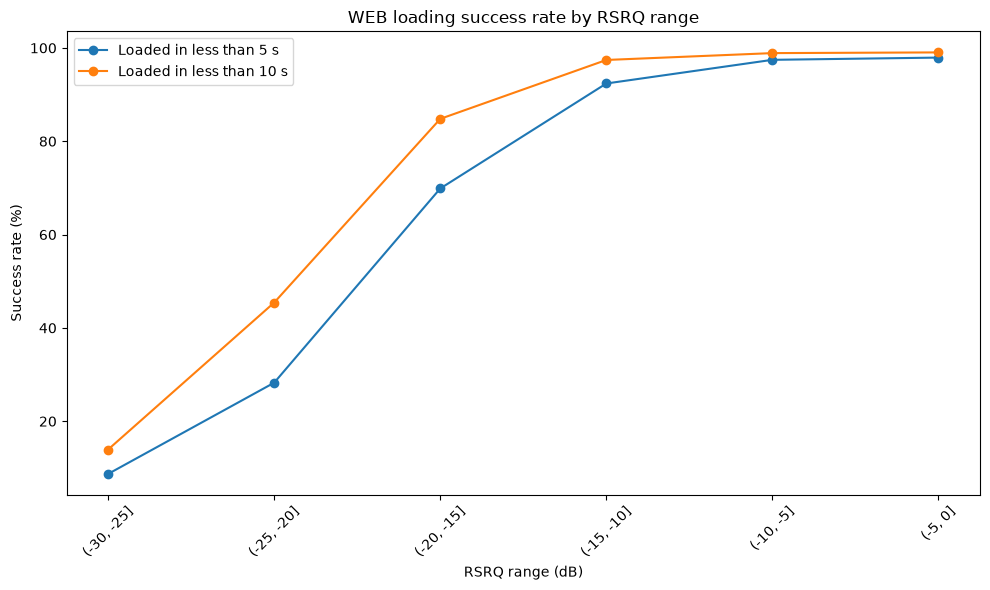

In [ ]:
web_rsrq_quality = (
    web_qos
    .groupby("rsrq_bin_5db", observed=True)[[
        "loaded_in_less_5_secondes",
        "loaded_in_less_10_secondes",
    ]]
    .agg(["count", "mean"])
)

web_rsrq_summary = pd.DataFrame({
    "count": web_rsrq_quality[("loaded_in_less_5_secondes", "count")],
    "under_5_pct": web_rsrq_quality[("loaded_in_less_5_secondes", "mean")] * 100,
    "under_10_pct": web_rsrq_quality[("loaded_in_less_10_secondes", "mean")] * 100,
}).round(2)

web_rsrq_plot = web_rsrq_summary.copy()
web_rsrq_plot.loc[
    web_rsrq_plot["count"] < MIN_GROUP_SIZE,
    ["under_5_pct", "under_10_pct"],
] = pd.NA

display(web_rsrq_summary)

plt.figure(figsize=(10, 6))
plt.plot(web_rsrq_plot.index.astype(str), web_rsrq_plot["under_5_pct"], marker="o", label="Loaded < 5 s")
plt.plot(web_rsrq_plot.index.astype(str), web_rsrq_plot["under_10_pct"], marker="o", label="Loaded < 10 s")
plt.xlabel("RSRQ range (dB)")
plt.ylabel("WEB success rate (%)")
plt.title("WEB loading success by RSRQ range")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### 7.1 WEB timeout handling

The raw access-duration distribution contains a strong concentration close to 10 seconds. Cross-checking `Result` shows that many of these observations are timeouts, meaning that a naive duration correlation would mix successful page loads with censored/limit values.

For that reason:

- binary loading-success indicators are analyzed on all WEB tests;
- `acess_duration` is analyzed only for rows where `Result == "Success"`.


In [ ]:
web_near_10s = web_qos.loc[
    web_qos["acess_duration"].between(9.5, 10.5),
    ["acess_duration", "loaded_in_less_10_secondes", "Result"],
].copy()

web_near_10s_summary = (
    web_near_10s
    .groupby(["loaded_in_less_10_secondes", "Result"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

web_near_10s_summary


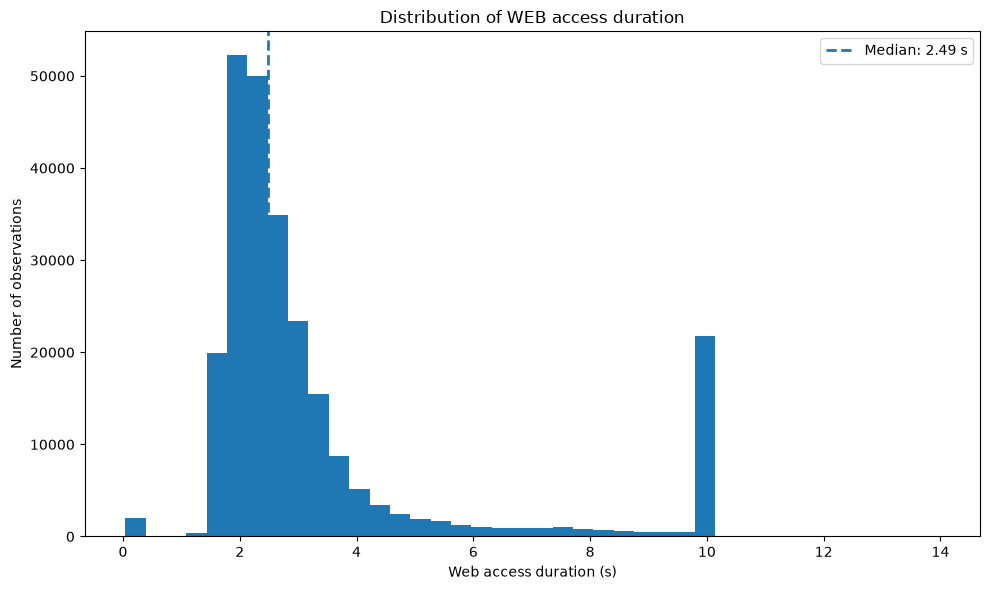

In [ ]:
web_access_median = web_qos["acess_duration"].median()

plt.figure(figsize=(10, 6))
plt.hist(web_qos["acess_duration"].dropna(), bins=40)
plt.axvline(
    web_access_median,
    linestyle="--",
    linewidth=2,
    label=f"Median: {web_access_median:.2f} s",
)
plt.xlabel("Web access duration (s)")
plt.ylabel("Number of observations")
plt.title("Distribution of WEB access duration")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
web_access_success = (
    web_qos.loc[
        web_qos["Result"] == "Success",
        [
            "operator",
            "rsrp",
            "rsrq",
            "acess_duration",
            "loaded_in_less_5_secondes",
            "loaded_in_less_10_secondes",
            "Result",
        ],
    ]
    .dropna(subset=["acess_duration"])
    .copy()
)

web_access_by_operator = (
    web_access_success
    .groupby("operator")["acess_duration"]
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
)

web_access_by_operator


In [ ]:
web_access_success["rsrp_bin_10db"] = pd.cut(
    web_access_success["rsrp"], bins=RSRP_BINS_10DB
)
web_access_success["rsrq_bin_5db"] = pd.cut(
    web_access_success["rsrq"], bins=RSRQ_BINS_5DB
)

web_access_rsrp_stats = (
    web_access_success
    .groupby("rsrp_bin_10db", observed=True)["acess_duration"]
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
)

web_access_rsrq_stats = (
    web_access_success
    .groupby("rsrq_bin_5db", observed=True)["acess_duration"]
    .describe()[["count", "25%", "50%", "75%"]]
    .round(2)
)

print("Successful WEB duration by RSRP")
display(web_access_rsrp_stats)
print("Successful WEB duration by RSRQ")
display(web_access_rsrq_stats)


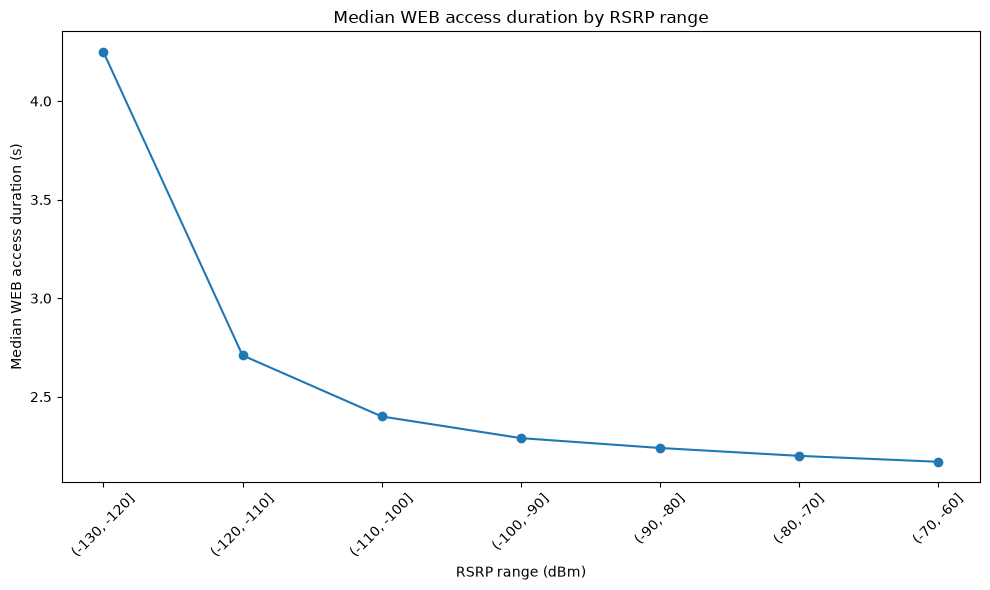

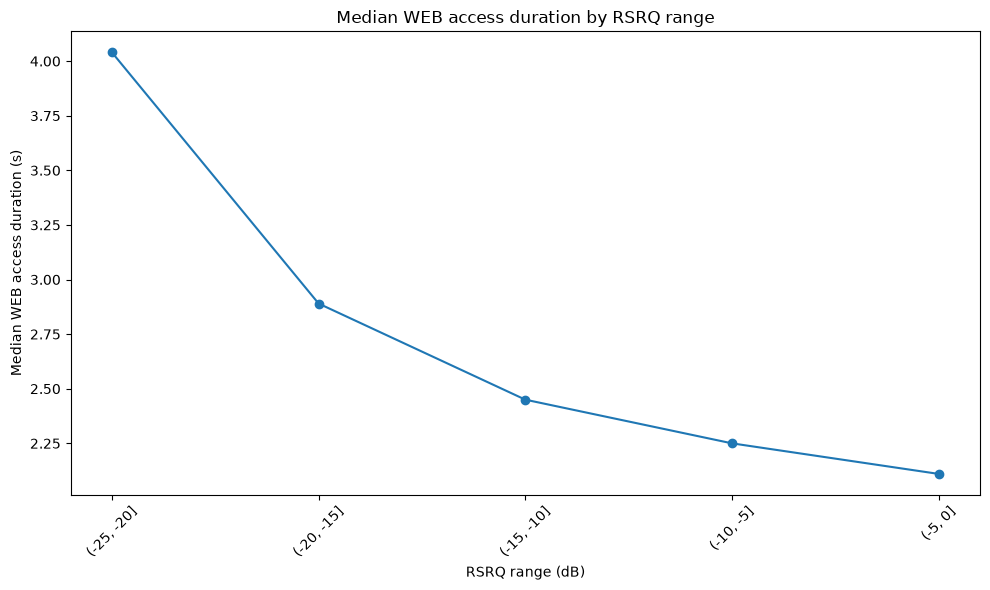

In [ ]:
web_access_rsrp_plot = web_access_rsrp_stats["50%"].copy()
web_access_rsrp_plot[web_access_rsrp_stats["count"] < MIN_GROUP_SIZE] = pd.NA

plt.figure(figsize=(10, 6))
plt.plot(web_access_rsrp_plot.index.astype(str), web_access_rsrp_plot.values, marker="o")
plt.xlabel("RSRP range (dBm)")
plt.ylabel("Median WEB access duration (s)")
plt.title("Successful WEB access duration by RSRP range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

web_access_rsrq_plot = web_access_rsrq_stats["50%"].copy()
web_access_rsrq_plot[web_access_rsrq_stats["count"] < MIN_GROUP_SIZE] = pd.NA

plt.figure(figsize=(10, 6))
plt.plot(web_access_rsrq_plot.index.astype(str), web_access_rsrq_plot.values, marker="o")
plt.xlabel("RSRQ range (dB)")
plt.ylabel("Median WEB access duration (s)")
plt.title("Successful WEB access duration by RSRQ range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
web_access_pearson = (
    web_access_success[["rsrp", "rsrq", "acess_duration"]]
    .corr(method="pearson")
    .round(3)
)

web_access_spearman = (
    web_access_success[["rsrp", "rsrq", "acess_duration"]]
    .corr(method="spearman")
    .round(3)
)

print("Pearson")
display(web_access_pearson)
print("Spearman")
display(web_access_spearman)


In [ ]:
web_access_operator_correlations = []

for operator in web_access_success["operator"].dropna().unique():
    operator_data = web_access_success[
        web_access_success["operator"] == operator
    ]

    web_access_operator_correlations.append({
        "operator": operator,
        "count": len(operator_data),
        "rsrp_pearson": operator_data["rsrp"].corr(
            operator_data["acess_duration"], method="pearson"
        ),
        "rsrp_spearman": operator_data["rsrp"].corr(
            operator_data["acess_duration"], method="spearman"
        ),
        "rsrq_pearson": operator_data["rsrq"].corr(
            operator_data["acess_duration"], method="pearson"
        ),
        "rsrq_spearman": operator_data["rsrq"].corr(
            operator_data["acess_duration"], method="spearman"
        ),
    })

web_access_operator_correlations = pd.DataFrame(
    web_access_operator_correlations
).round(3)

web_access_operator_correlations


### WEB findings

The WEB results show a clear **transition-and-plateau** pattern:

- in weak radio classes, the probability of loading within 5 or 10 seconds is substantially lower;
- as RSRP/RSRQ improve, success rates rise rapidly;
- once the radio conditions become sufficiently favorable in this sample, the curves approach a high-success plateau and additional radio improvement produces much smaller gains.

For successful WEB tests, better RSRP/RSRQ is also associated with shorter access duration, although the relationship is moderate rather than deterministic. This is expected because page loading also depends on DNS/TCP/TLS setup, server response, transport/core-network delay and content characteristics.

The timeout investigation is essential. Observations concentrated close to the 10-second limit are censored failures and must not be treated as ordinary successful loading durations.


## 8. STREAM Quality of Experience

STREAM performance is represented by two binary indicators: `quality_correct` and `quality_perfect`.

Before relating them to the radio layer, the notebook checks their internal logic and their relationship with `Result`. This prevents a common analytical mistake: assuming that two similarly named success indicators are interchangeable without verifying how they are populated.

The subsequent RSRP/RSRQ curves are interpreted as success proportions within each radio bin, using the same minimum-sample visualization rule as the throughput and WEB sections.


In [ ]:
stream_qos = (
    df_clean.loc[
        df_clean["protocole"] == "STREAM",
        [
            "operator",
            "rsrp",
            "rsrq",
            "acess_duration",
            "quality_correct",
            "quality_perfect",
            "Result",
        ],
    ]
    .copy()
)

quality_inconsistency = (
    (stream_qos["quality_perfect"] == 1)
    & (stream_qos["quality_correct"] == 0)
).sum()

print("Perfect-but-not-correct inconsistencies:", int(quality_inconsistency))

display(pd.crosstab(
    stream_qos["quality_correct"],
    stream_qos["quality_perfect"],
    margins=True,
))

display(pd.crosstab(
    stream_qos["Result"],
    [stream_qos["quality_correct"], stream_qos["quality_perfect"]],
    margins=True,
))


In [ ]:
stream_quality_by_operator = (
    stream_qos
    .groupby("operator")[["quality_correct", "quality_perfect"]]
    .mean()
    .mul(100)
    .round(2)
)

stream_quality_by_operator


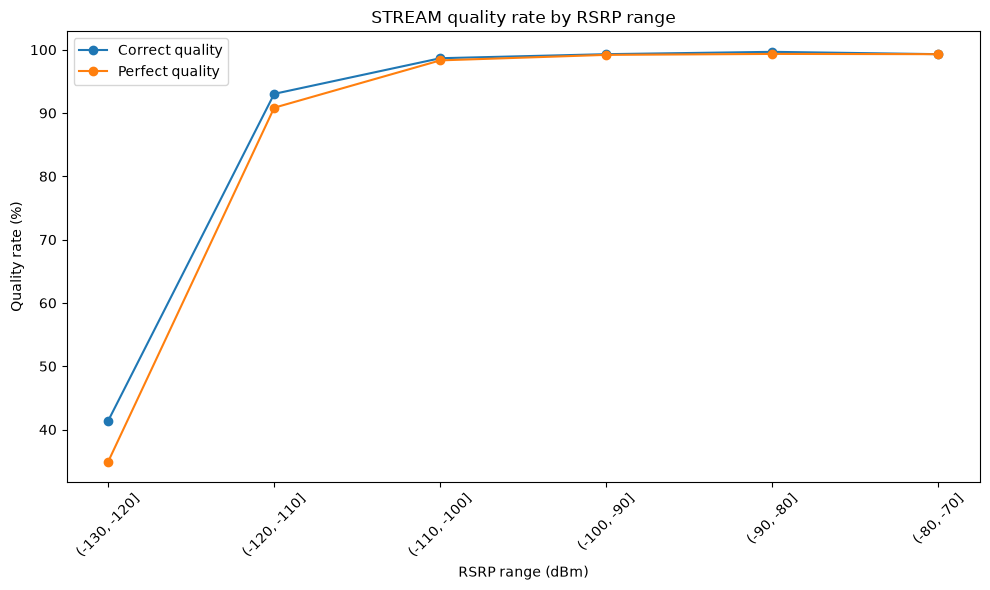

In [ ]:
stream_qos["rsrp_bin_10db"] = pd.cut(
    stream_qos["rsrp"], bins=RSRP_BINS_10DB
)
stream_qos["rsrq_bin_5db"] = pd.cut(
    stream_qos["rsrq"], bins=RSRQ_BINS_5DB
)

stream_rsrp_quality = (
    stream_qos
    .groupby("rsrp_bin_10db", observed=True)[
        ["quality_correct", "quality_perfect"]
    ]
    .agg(["count", "mean"])
)

stream_rsrp_summary = pd.DataFrame({
    "count": stream_rsrp_quality[("quality_correct", "count")],
    "correct_pct": stream_rsrp_quality[("quality_correct", "mean")] * 100,
    "perfect_pct": stream_rsrp_quality[("quality_perfect", "mean")] * 100,
}).round(2)

stream_rsrp_plot = stream_rsrp_summary.copy()
stream_rsrp_plot.loc[
    stream_rsrp_plot["count"] < MIN_GROUP_SIZE,
    ["correct_pct", "perfect_pct"],
] = pd.NA

display(stream_rsrp_summary)

plt.figure(figsize=(10, 6))
plt.plot(stream_rsrp_plot.index.astype(str), stream_rsrp_plot["correct_pct"], marker="o", label="Correct quality")
plt.plot(stream_rsrp_plot.index.astype(str), stream_rsrp_plot["perfect_pct"], marker="o", label="Perfect quality")
plt.xlabel("RSRP range (dBm)")
plt.ylabel("STREAM quality rate (%)")
plt.title("STREAM quality by RSRP range")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


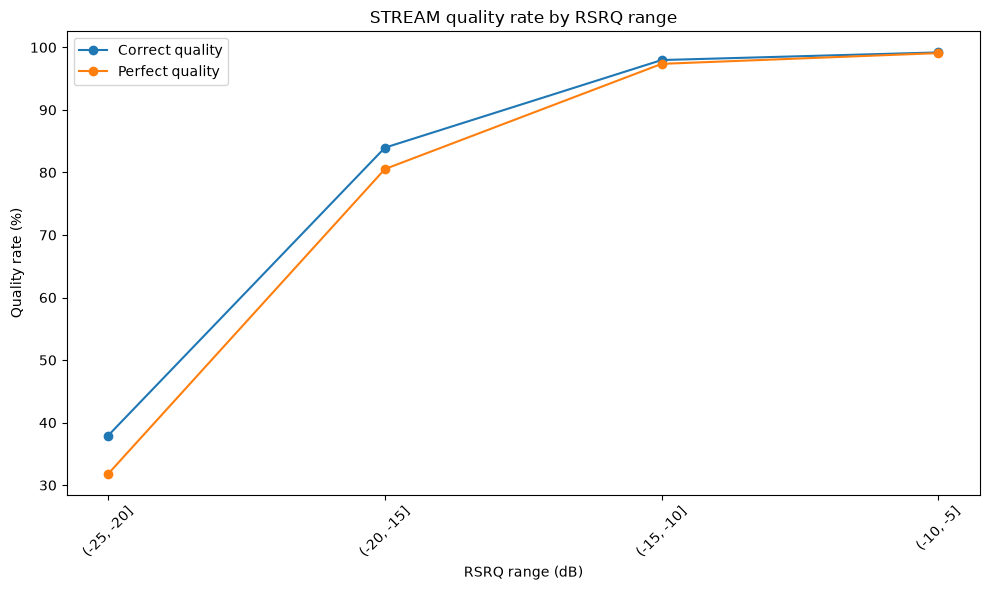

In [ ]:
stream_rsrq_quality = (
    stream_qos
    .groupby("rsrq_bin_5db", observed=True)[
        ["quality_correct", "quality_perfect"]
    ]
    .agg(["count", "mean"])
)

stream_rsrq_summary = pd.DataFrame({
    "count": stream_rsrq_quality[("quality_correct", "count")],
    "correct_pct": stream_rsrq_quality[("quality_correct", "mean")] * 100,
    "perfect_pct": stream_rsrq_quality[("quality_perfect", "mean")] * 100,
}).round(2)

stream_rsrq_plot = stream_rsrq_summary.copy()
stream_rsrq_plot.loc[
    stream_rsrq_plot["count"] < MIN_GROUP_SIZE,
    ["correct_pct", "perfect_pct"],
] = pd.NA

display(stream_rsrq_summary)

plt.figure(figsize=(10, 6))
plt.plot(stream_rsrq_plot.index.astype(str), stream_rsrq_plot["correct_pct"], marker="o", label="Correct quality")
plt.plot(stream_rsrq_plot.index.astype(str), stream_rsrq_plot["perfect_pct"], marker="o", label="Perfect quality")
plt.xlabel("RSRQ range (dB)")
plt.ylabel("STREAM quality rate (%)")
plt.title("STREAM quality by RSRQ range")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
stream_pearson_corr = (
    stream_qos[["rsrp", "rsrq", "quality_correct", "quality_perfect"]]
    .corr(method="pearson")
    .round(3)
)

stream_spearman_corr = (
    stream_qos[["rsrp", "rsrq", "quality_correct", "quality_perfect"]]
    .corr(method="spearman")
    .round(3)
)

print("Pearson")
display(stream_pearson_corr)
print("Spearman")
display(stream_spearman_corr)


In [ ]:
stream_operator_correlations = []

for operator in stream_qos["operator"].dropna().unique():
    operator_data = stream_qos[stream_qos["operator"] == operator]

    stream_operator_correlations.append({
        "operator": operator,
        "count": len(operator_data),
        "rsrp_correct": operator_data["rsrp"].corr(
            operator_data["quality_correct"], method="pearson"
        ),
        "rsrp_perfect": operator_data["rsrp"].corr(
            operator_data["quality_perfect"], method="pearson"
        ),
        "rsrq_correct": operator_data["rsrq"].corr(
            operator_data["quality_correct"], method="pearson"
        ),
        "rsrq_perfect": operator_data["rsrq"].corr(
            operator_data["quality_perfect"], method="pearson"
        ),
    })

stream_operator_correlations = pd.DataFrame(
    stream_operator_correlations
).round(3)

stream_operator_correlations


### STREAM findings

`quality_perfect` is consistently nested inside `quality_correct`: no observation is marked perfect while being marked incorrect. This confirms the expected logical hierarchy between the two indicators in this dataset.

Both success rates improve markedly as radio conditions improve and then approach a plateau. The transition is especially visible in the lower RSRQ classes, while the strongest radio classes show little remaining room for improvement.

RSRQ has a slightly stronger global Pearson association with the two STREAM quality indicators than RSRP in this sample. Because the quality indicators are binary and strongly nested, these coefficients should be treated as complementary summaries; the binned success curves provide the more intuitive engineering interpretation.


## 9. ULH upload reliability

The ULH protocol is analyzed through `upload_ok`, a binary indicator of upload success.

The first check compares `upload_ok` with the protocol `Result`. In this dataset, the indicator cleanly separates successful ULH tests from `Traffic Fail` and `Drop` outcomes, so it can be used as a reliable success variable for the radio analysis.

As with the other binary KPIs, the mean of `upload_ok` within a group is interpreted directly as the upload success rate.


In [ ]:
ulh_qos = (
    df_clean.loc[
        df_clean["protocole"] == "ULH",
        [
            "operator",
            "rsrp",
            "rsrq",
            "acess_duration",
            "upload_ok",
            "Result",
        ],
    ]
    .copy()
)

display(pd.crosstab(
    ulh_qos["Result"],
    ulh_qos["upload_ok"],
    margins=True,
))

ulh_success_by_operator = (
    ulh_qos
    .groupby("operator")["upload_ok"]
    .agg(["count", "mean"])
)
ulh_success_by_operator["success_pct"] = (
    ulh_success_by_operator["mean"] * 100
).round(2)
ulh_success_by_operator["failure_pct"] = (
    100 - ulh_success_by_operator["success_pct"]
).round(2)

ulh_success_by_operator


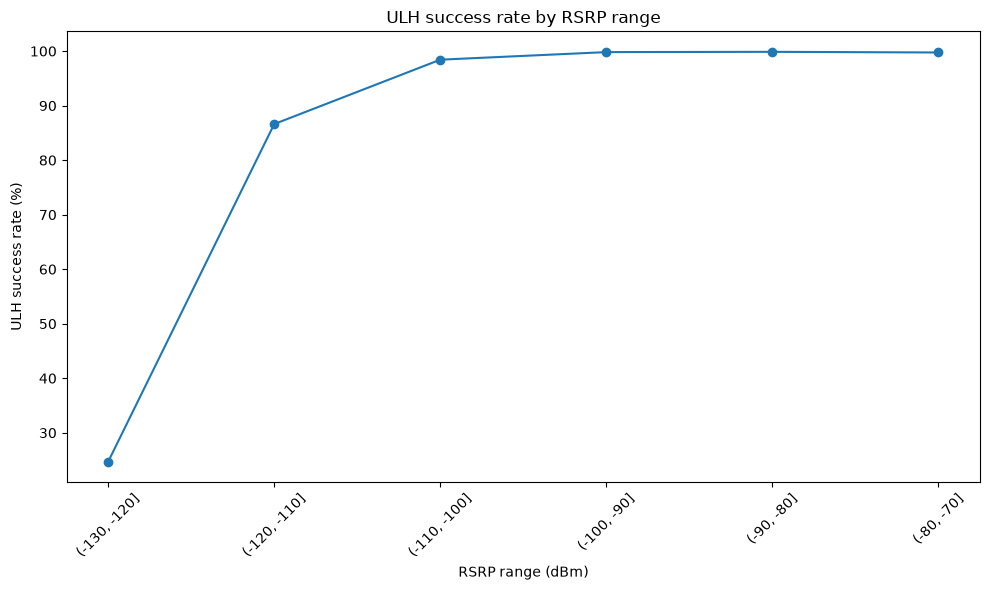

In [ ]:
ulh_qos["rsrp_bin_10db"] = pd.cut(
    ulh_qos["rsrp"], bins=RSRP_BINS_10DB
)
ulh_qos["rsrq_bin_5db"] = pd.cut(
    ulh_qos["rsrq"], bins=RSRQ_BINS_5DB
)

ulh_rsrp_success = (
    ulh_qos
    .groupby("rsrp_bin_10db", observed=True)["upload_ok"]
    .agg(["count", "mean"])
)
ulh_rsrp_success["success_pct"] = (
    ulh_rsrp_success["mean"] * 100
).round(2)

ulh_rsrp_plot = ulh_rsrp_success.copy()
ulh_rsrp_plot.loc[
    ulh_rsrp_plot["count"] < MIN_GROUP_SIZE,
    "success_pct",
] = pd.NA

display(ulh_rsrp_success)

plt.figure(figsize=(10, 6))
plt.plot(
    ulh_rsrp_plot.index.astype(str),
    ulh_rsrp_plot["success_pct"],
    marker="o",
)
plt.xlabel("RSRP range (dBm)")
plt.ylabel("ULH success rate (%)")
plt.title("ULH success rate by RSRP range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


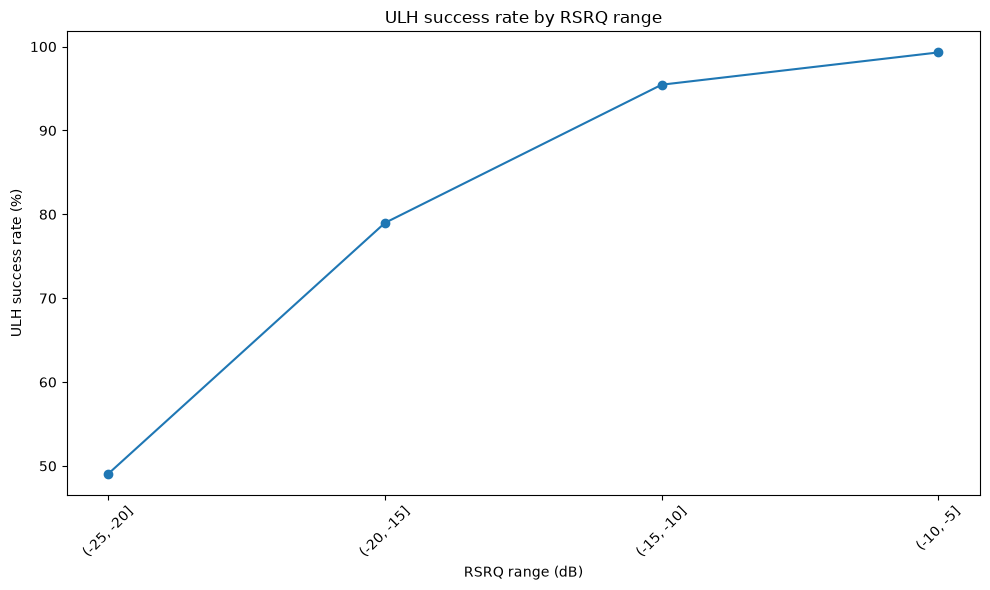

In [ ]:
ulh_rsrq_success = (
    ulh_qos
    .groupby("rsrq_bin_5db", observed=True)["upload_ok"]
    .agg(["count", "mean"])
)
ulh_rsrq_success["success_pct"] = (
    ulh_rsrq_success["mean"] * 100
).round(2)

ulh_rsrq_plot = ulh_rsrq_success.copy()
ulh_rsrq_plot.loc[
    ulh_rsrq_plot["count"] < MIN_GROUP_SIZE,
    "success_pct",
] = pd.NA

display(ulh_rsrq_success)

plt.figure(figsize=(10, 6))
plt.plot(
    ulh_rsrq_plot.index.astype(str),
    ulh_rsrq_plot["success_pct"],
    marker="o",
)
plt.xlabel("RSRQ range (dB)")
plt.ylabel("ULH success rate (%)")
plt.title("ULH success rate by RSRQ range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
ulh_radio_corr = (
    ulh_qos[["rsrp", "rsrq", "upload_ok"]]
    .corr(method="pearson")
    .round(3)
)

ulh_radio_corr


### ULH findings

`upload_ok` matches the ULH success/failure result structure in this dataset, which gives confidence in using it as the protocol reliability KPI.

The success-rate curves rise sharply as RSRP and RSRQ improve, then reach a near-saturation region. This nonlinear shape is more informative than a single global coefficient: most of the practical change occurs in the weaker and intermediate radio ranges, while the strongest ranges are already close to maximum success.

Pearson coefficients are positive and similar for RSRP and RSRQ because successful uploads become more frequent under better radio conditions. Operator-level success rates differ in the observed campaign, but those differences remain descriptive and should not be generalized beyond the measurement conditions.


## 10. Protocol result overview

`Result` is retained as a contextual field. Percentages are calculated within each protocol, but these statuses should not be compared as if every protocol used the same failure mechanism or success criterion.


In [ ]:
result_rate_by_protocol = (
    pd.crosstab(
        df_clean["protocole"],
        df_clean["Result"],
        normalize="index",
        dropna=False,
    )
    .mul(100)
    .round(2)
)

result_rate_by_protocol


## 11. Key findings

1. **Radio conditions and throughput are positively associated.** In the full DL sample, Spearman correlation is about **0.56** for RSRP versus bitrate and **0.37** for RSRQ versus bitrate.
2. **Uplink bitrate is much more tightly associated with RSRP.** The global Spearman coefficient reaches about **0.85**, and the operator-level values are consistently high.
3. **WEB loading performance improves strongly with better radio conditions**, with a transition from low success rates in weak-radio classes toward a high-success plateau.
4. **WEB access duration requires censoring awareness.** A large group of timeout observations is concentrated close to 10 seconds, so successful durations are analyzed separately.
5. **STREAM correct/perfect quality indicators are logically consistent and strongly nested.** Their success rates rise with improving RSRP/RSRQ and then plateau.
6. **ULH upload reliability follows the same broad radio pattern.** In the observed sample, operator success rates range from roughly **86% to 93%**, while RSRP and RSRQ have similar positive associations with `upload_ok`.

These are descriptive findings from this ARCEP measurement campaign, not causal estimates or universal operator rankings.


## 12. Methodological limitations

The analysis is intentionally cautious because the dataset is observational rather than experimental.

- **Correlation is not causation.** RSRP/RSRQ and QoS move together, but the notebook does not prove that changing only one radio metric would produce the observed KPI change.
- **Measurement context matters.** Results reflect the locations, dates, devices, protocols and network state present during the ARCEP campaign.
- **Radio metrics are only part of the performance chain.** Spectrum allocation, scheduler behaviour, cell load, interference, MIMO conditions, device category, transport/core-network conditions and remote servers can all affect the observed KPIs.
- **Protocol-specific sample sizes differ.** Some KPIs contain far fewer observations than the complete dataset because they are populated only for the corresponding test protocol.
- **Sparse-bin masking is visual only.** The `<100 observations` rule prevents visually over-interpreting small groups; it is neither a telecom threshold nor a formal statistical significance criterion, and no underlying row is deleted.
- **Operator comparision remains campaign-specific.** Even when operators are compared inside the same RSRP/RSRQ bins, the remaining technical conditions are not fully controlled.

These limitations do not invalidate the analysis; they define what can and cannot be concluded from it.


## 13. Conclusion

This project demonstrates an end-to-end QoS analysis workflow combining data-quality controls, protocol-specific filtering, radio measurements, throughput statistics and user-experience indicators.

Across the analyzed protocols, stronger radio conditions are generally associated with better user-facing performance. The strength of the relationship varies by KPI: RSRP is especially informative for uplink throughput, while WEB and STREAM metrics show nonlinear transition-and-plateau behaviour.

The analysis also highlights an important engineering lesson: **radio quality is a major contributor to QoS, but it is not the only one**. Robust diagnosis requires combining radio conditions with service-specific indicators and contextual network information.


## 14. References

- **ARCEP Open Data — Mesures de qualité de service réalisées par l'Arcep**  
  https://data.arcep.fr/mobile/mesures_qualite_arcep/
- **ARCEP Open Data — 2025 Metropolitan dataset**  
  https://data.arcep.fr/mobile/mesures_qualite_arcep/2025/Metropole/index.html
- **ARCEP — Qualité des services mobiles en métropole, campagne 2025**  
  https://www.arcep.fr/actualites/actualites-et-communiques/detail/n/qualite-des-services-mobiles-en-metropole-201125.html
- **ARCEP — La qualité des services mobiles**  
  https://www.arcep.fr/la-regulation/grands-dossiers-reseaux-mobiles/la-qualite-des-services-mobiles.html

The code uses `pandas`, `matplotlib` and `scipy` (through Pandas for Spearman correlation).


## 15. Optional export of the cleaned dataset

The processed file is written to a separate directory so that the original ARCEP dataset remains unchanged.


In [ ]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_path = (
    PROCESSED_DIR
    / "2025_QoS_Metropole_data_habitations_clean.csv"
)

df_clean.to_csv(
    processed_path,
    sep=";",
    encoding="utf-8-sig",
    index=False,
)

processed_path
